# Model_experiments
---
Ahora toca probar el modelo que capta la tendencia con un modelo lineal y luego capturaremos la estacionalidad y lo ciclico con un modelo XGBoost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

In [2]:
families = ['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS',
       'BREAD_BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS',
       'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE',
       'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES',
       'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE',
       'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE',
       'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY', 'PREPARED FOODS',
       'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD']

dataframes = {}

for family in families:
    print(family)
    df_train = pd.read_csv(f'../data/processed/LinearandXGBoost/train/{family}_train.csv', parse_dates=['date'], index_col='date')
    df_test = pd.read_csv(f'../data/processed/LinearandXGBoost/test/{family}_test.csv', parse_dates=['date'], index_col='date')
    dataframes[family] = (df_train, df_test)


AUTOMOTIVE
BABY CARE
BEAUTY
BEVERAGES
BOOKS
BREAD_BAKERY
CELEBRATION
CLEANING
DAIRY
DELI
EGGS
FROZEN FOODS
GROCERY I
GROCERY II
HARDWARE
HOME AND KITCHEN I
HOME AND KITCHEN II
HOME APPLIANCES
HOME CARE
LADIESWEAR
LAWN AND GARDEN
LINGERIE
LIQUOR,WINE,BEER
MAGAZINES
MEATS
PERSONAL CARE
PET SUPPLIES
PLAYERS AND ELECTRONICS
POULTRY
PREPARED FOODS
PRODUCE
SCHOOL AND OFFICE SUPPLIES
SEAFOOD


In [3]:
models = {}

for family, (train_df, test_df) in dataframes.items():
    # Entrenamos el modelo de regresión lineal
    model = LinearRegression()
    model.fit(train_df[['days_since_start']], train_df['sales'])
    
    # Guardamos el modelo entrenado en el diccionario
    models[family] = model

AUTOMOTIVE


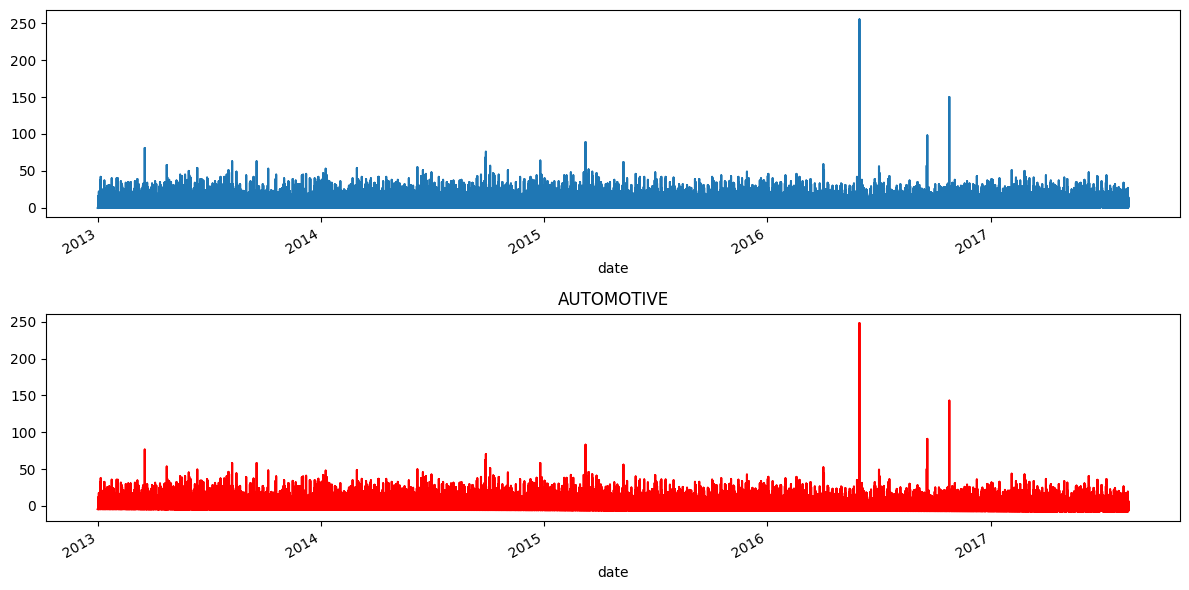

BABY CARE


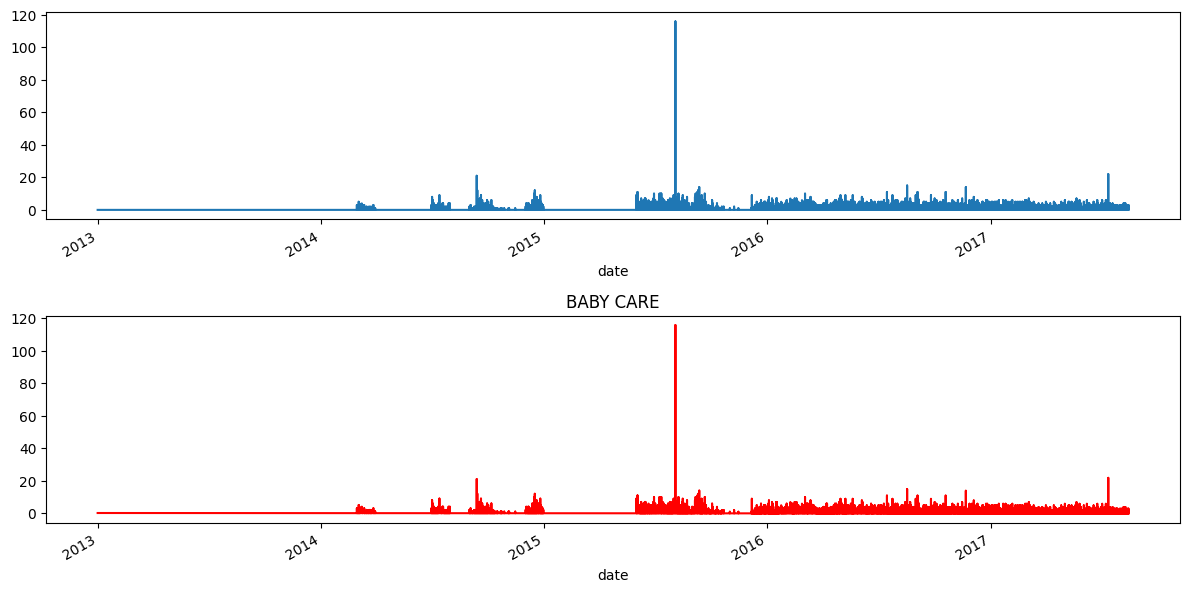

BEAUTY


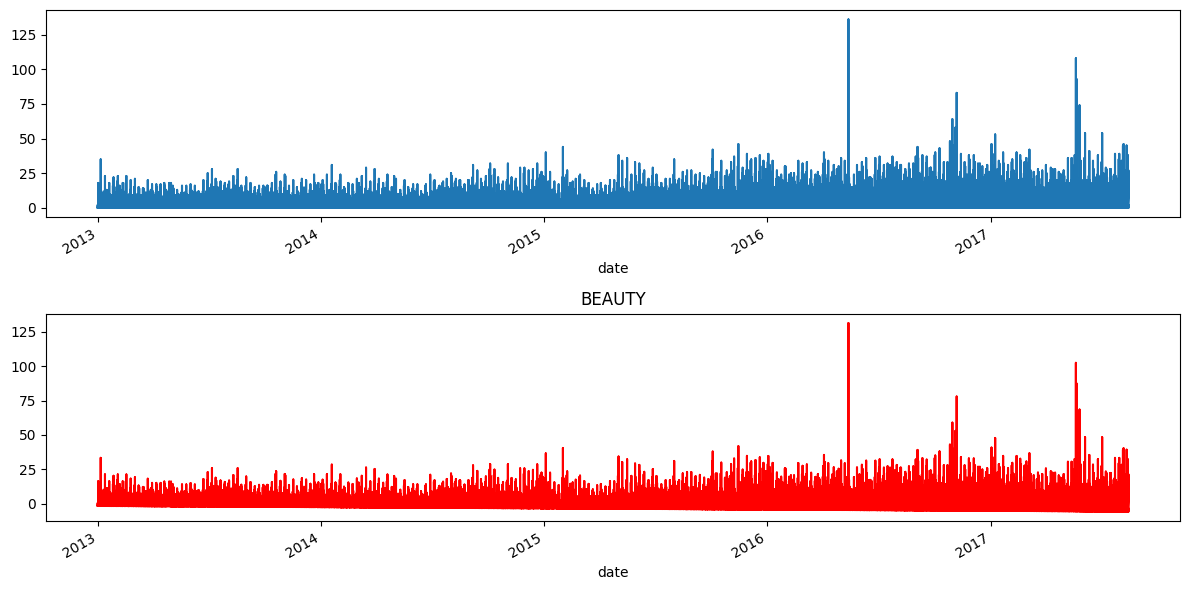

BEVERAGES


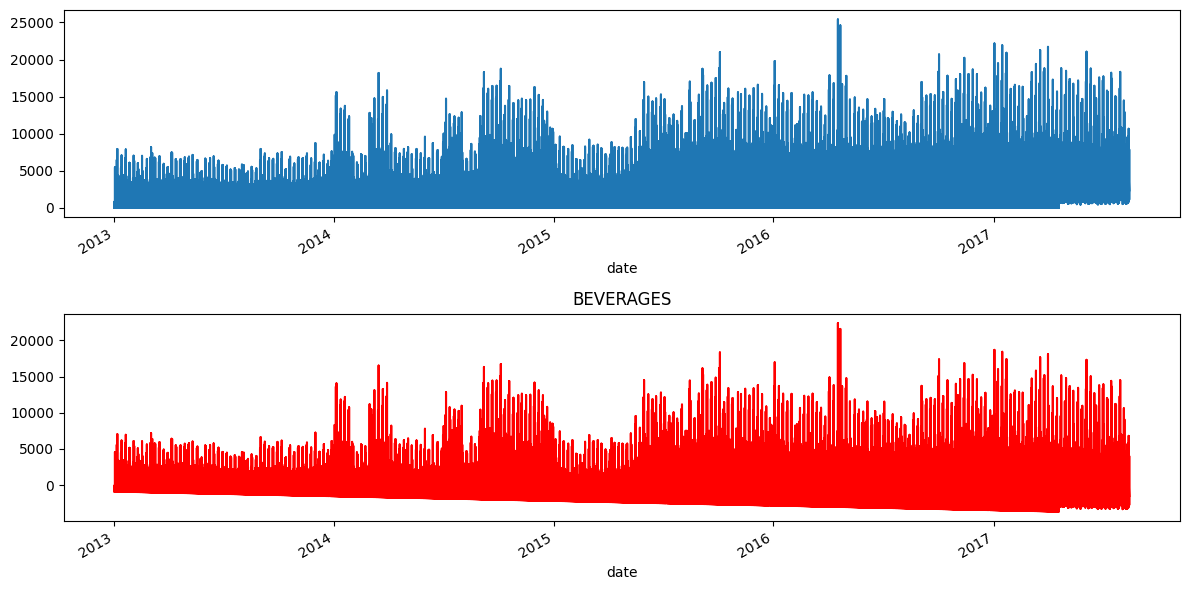

BOOKS


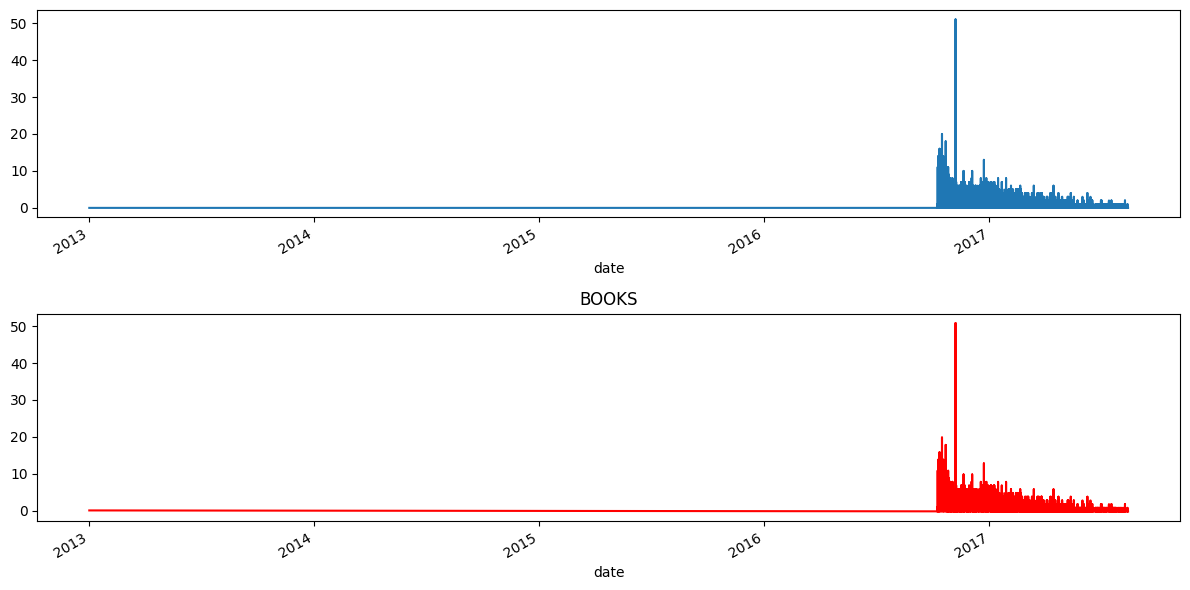

In [4]:
#Prueba para ver si se ha quitado la estacionalidad de los datos

dataframe_trend = models['AUTOMOTIVE'].predict(dataframes['AUTOMOTIVE'][0][['days_since_start']])

dataframe_without_trend = dataframes['AUTOMOTIVE'][0]['sales'] - dataframe_trend

NUM_FAMILIES = 5 #Variable que puedes cambiar para ver más o menos familias en el gráfico
for family, data in list(dataframes.items())[:NUM_FAMILIES]:
    print(family)
    dataframe_trend = models[family].predict(data[0][['days_since_start']])
    dataframe_without_trend = data[0]['sales'] - dataframe_trend
    fig = plt.figure(figsize=(12, 12))
    ax1 = fig.add_subplot(211)
    ax2 = fig.add_subplot(212)
    data[0]['sales'].plot(label='Train', figsize=(12, 6), ax=ax1)
    dataframe_without_trend.plot(label='Without Trend',color='red', figsize=(12, 6), ax=ax2)
    plt.title(family)
    plt.tight_layout()
    plt.show()
    

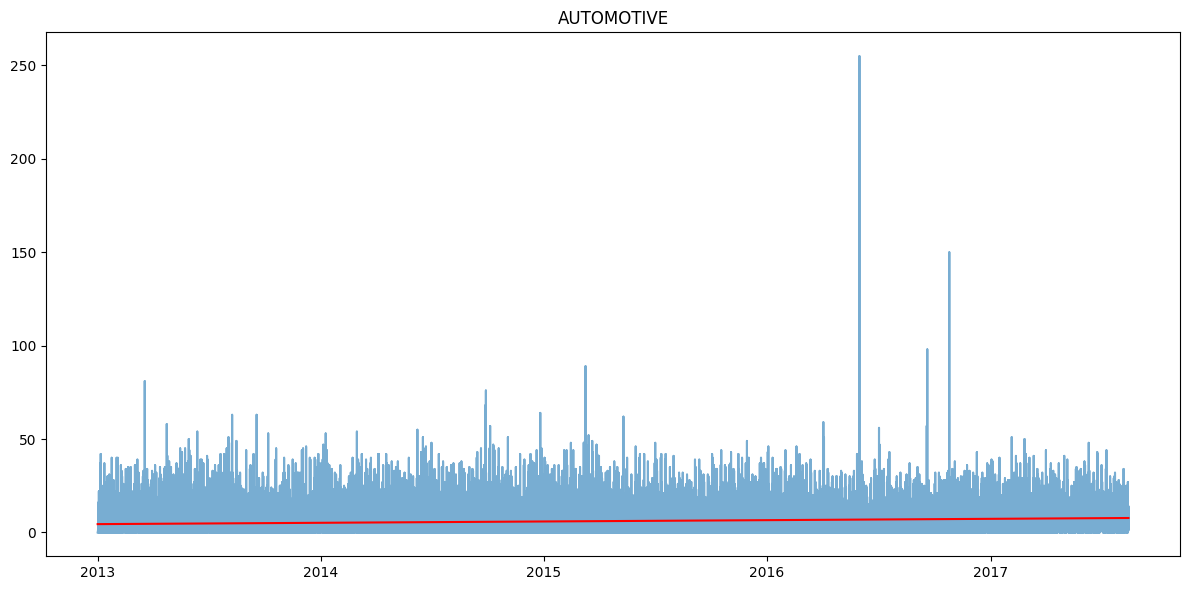

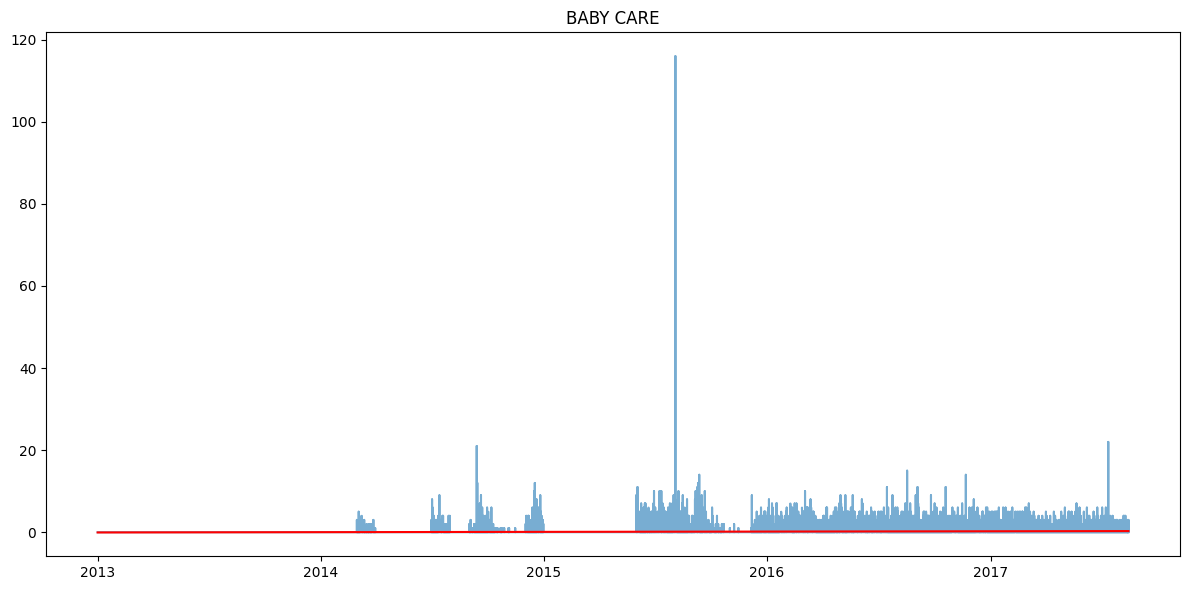

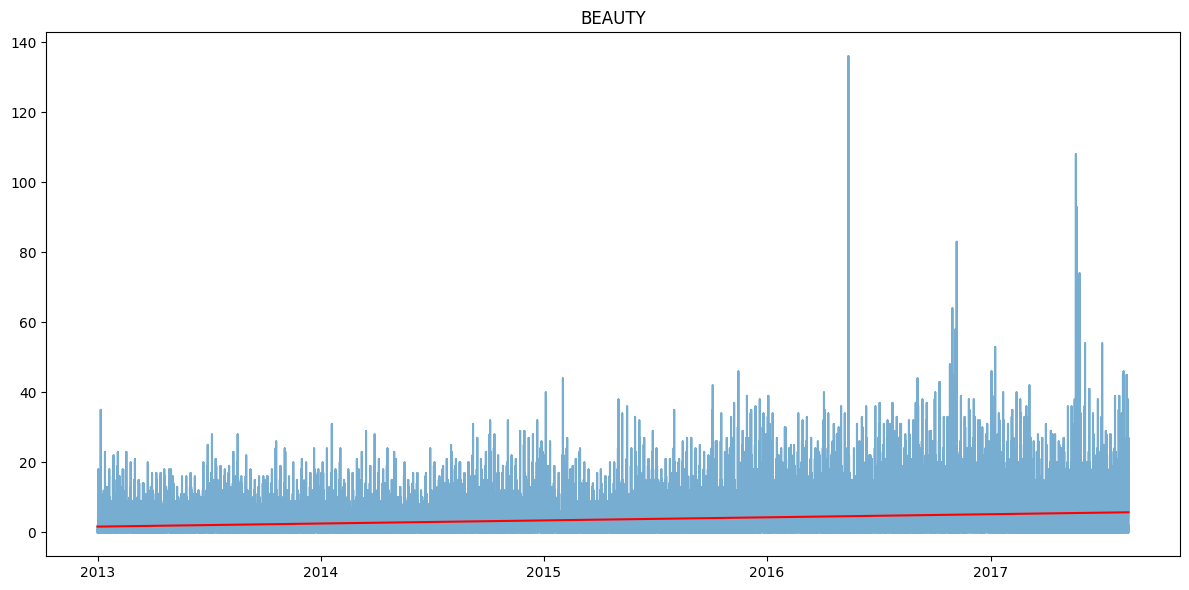

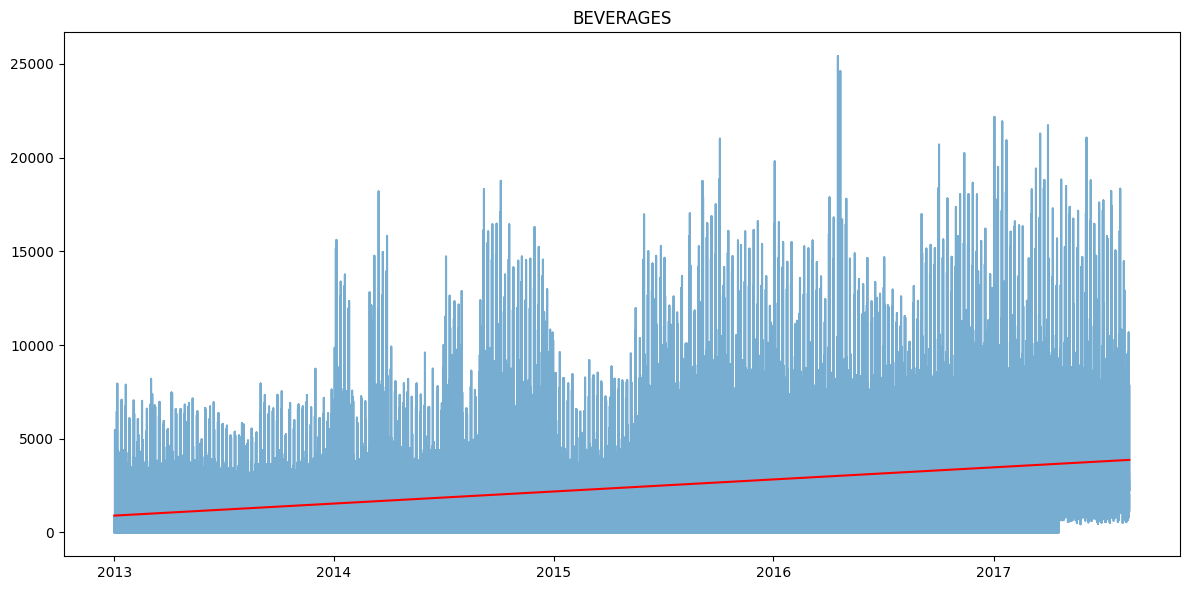

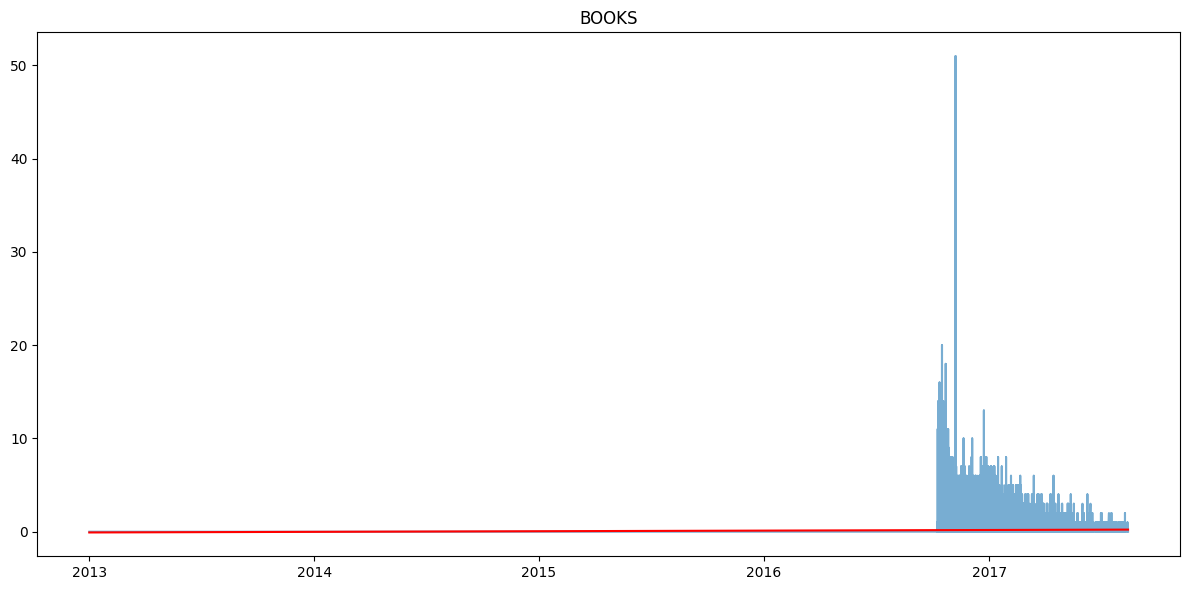

In [5]:
#Y ahora lo mismo pero viendo la linea que predice el modelo de regresión lineal junto con los datos de train

NUM_FAMILIES = 5 #Variable que puedes cambiar para ver más o menos familias en el gráfico
for family, data in list(dataframes.items())[:NUM_FAMILIES]:
    max_day = data[0][['days_since_start']].max()
    trend = models[family].predict(data[0][['days_since_start']])

    #El plot con la linea de los datos de tendencia y los datos de train
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(data[0].index, data[0]["sales"], label="Train", alpha=0.6)
    ax.plot(data[0].index, trend, label='Trend', color='red')

    ax.set_title(family)
    plt.tight_layout()
    plt.show()


Para algunos viene bien pero para otros la verdad que no ayuda mucho, pero de todas formas seguiremos para ver los resultados

In [6]:
models_XGBoost = {}

for family, (train_df, test_df) in dataframes.items():
    # Convertimos store_nbr a category para que XGBoost lo maneje como categórico
    train_df['store_nbr'] = train_df['store_nbr'].astype('category')
    
    model = XGBRegressor(enable_categorical=True)
    train_df_xgb = train_df.drop(['days_since_start', 'sales'], axis=1)
    target_without_trend = train_df['sales'] - models[family].predict(train_df[['days_since_start']])
    model.fit(train_df_xgb, target_without_trend)
    
    # Guardamos el modelo entrenado en el diccionario
    models_XGBoost[family] = model

Pasaremos ahora el test.csv por los modelos de regresión lineal y XGBoost y veremos los resultados

In [8]:
test = pd.read_csv(f'../data/raw/store-sales-time-series-forecasting/test.csv', parse_dates=['date'])
test['days_since_start'] = (test['date'] - dataframes['AUTOMOTIVE'][0].index.min()).dt.days + 1

# Convertimos store_nbr a category para que XGBoost lo maneje como categórico
test['store_nbr'] = test['store_nbr'].astype('category')

test['Month'] = test['date'].dt.month # int64
test['Day'] = test['date'].dt.day # int64
test.set_index('date', inplace=True)

test.head()

,id,store_nbr,family,onpromotion,days_since_start,Month,Day
date,,,,,,,
2017-08-16,3000888,1,AUTOMOTIVE,0,1689,8,16
2017-08-16,3000889,1,BABY CARE,0,1689,8,16
2017-08-16,3000890,1,BEAUTY,2,1689,8,16
2017-08-16,3000891,1,BEVERAGES,20,1689,8,16
2017-08-16,3000892,1,BOOKS,0,1689,8,16


In [12]:
test['sales'] = 0.0  # Inicializamos la columna de ventas con ceros

for family in dataframes.keys():
    family_for_mask = family.replace("_", "/")  # Reemplaza las barras por guiones bajos en el nombre de la familia
    mask = test['family'] == family_for_mask

    if mask.any():
        #Prediccion de la tendencia con el modelo de regresión lineal
        trend = models[family].predict(test[mask][['days_since_start']])
        #Y ahora la estacionalidad
        seasonality_data = test.drop(columns=['days_since_start', 'family','id', 'sales'], axis=1)
        features = list(models_XGBoost[family].feature_names_in_)
        seasonality = models_XGBoost[family].predict(seasonality_data.loc[mask,features])

        #Suma para la prediccion final
        prediction = trend + seasonality

        #Ponemos 0 a los valores negativos de la predicción ya que no puede haber ventas negativas
        prediction[prediction < 0] = 0

        test.loc[mask, 'sales'] = prediction

test_submission = test.drop(columns=['days_since_start', 'Month', 'Day', 'onpromotion', 'family'])
test_submission = test_submission.loc[:,['id', 'sales']]
print(test_submission.head())

# Guardamos el archivo de predicciones en un archivo csv
test_submission.to_csv('../data/processed/LinearandXGBoost/predictions.csv', index=False)



                 id        sales
date                            
2017-08-16  3000888     5.188709
2017-08-16  3000889     0.174234
2017-08-16  3000890     5.866157
2017-08-16  3000891  2465.691498
2017-08-16  3000892     0.174745
